<a href="https://colab.research.google.com/github/dragstoll/Hands-On-Python-Natural-Language-Processing/blob/master/travel_agent_crewai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧳 Travel Agent with CrewAI

> **GenAI Zürich 2026** — The European Summit on Applied Generative AI
>
> Workshop: *Designing LLM Agents: Frameworks, Architectures, and Trade-offs*
> David Limacher & Julian Schelb — [Artifact SA](https://artifact.swiss)

***

In this notebook we build a **multi-agent travel assistant** using [CrewAI](https://docs.crewai.com/), a framework for orchestrating teams of specialised AI agents. Instead of a single agent doing everything, **seven agents** are arranged in a **three-tier hierarchy**: a Manager LLM at the top delegates to Team Leads, who in turn delegate to specialist agents. This structure demonstrates how `Process.hierarchical` enables cascading delegation.
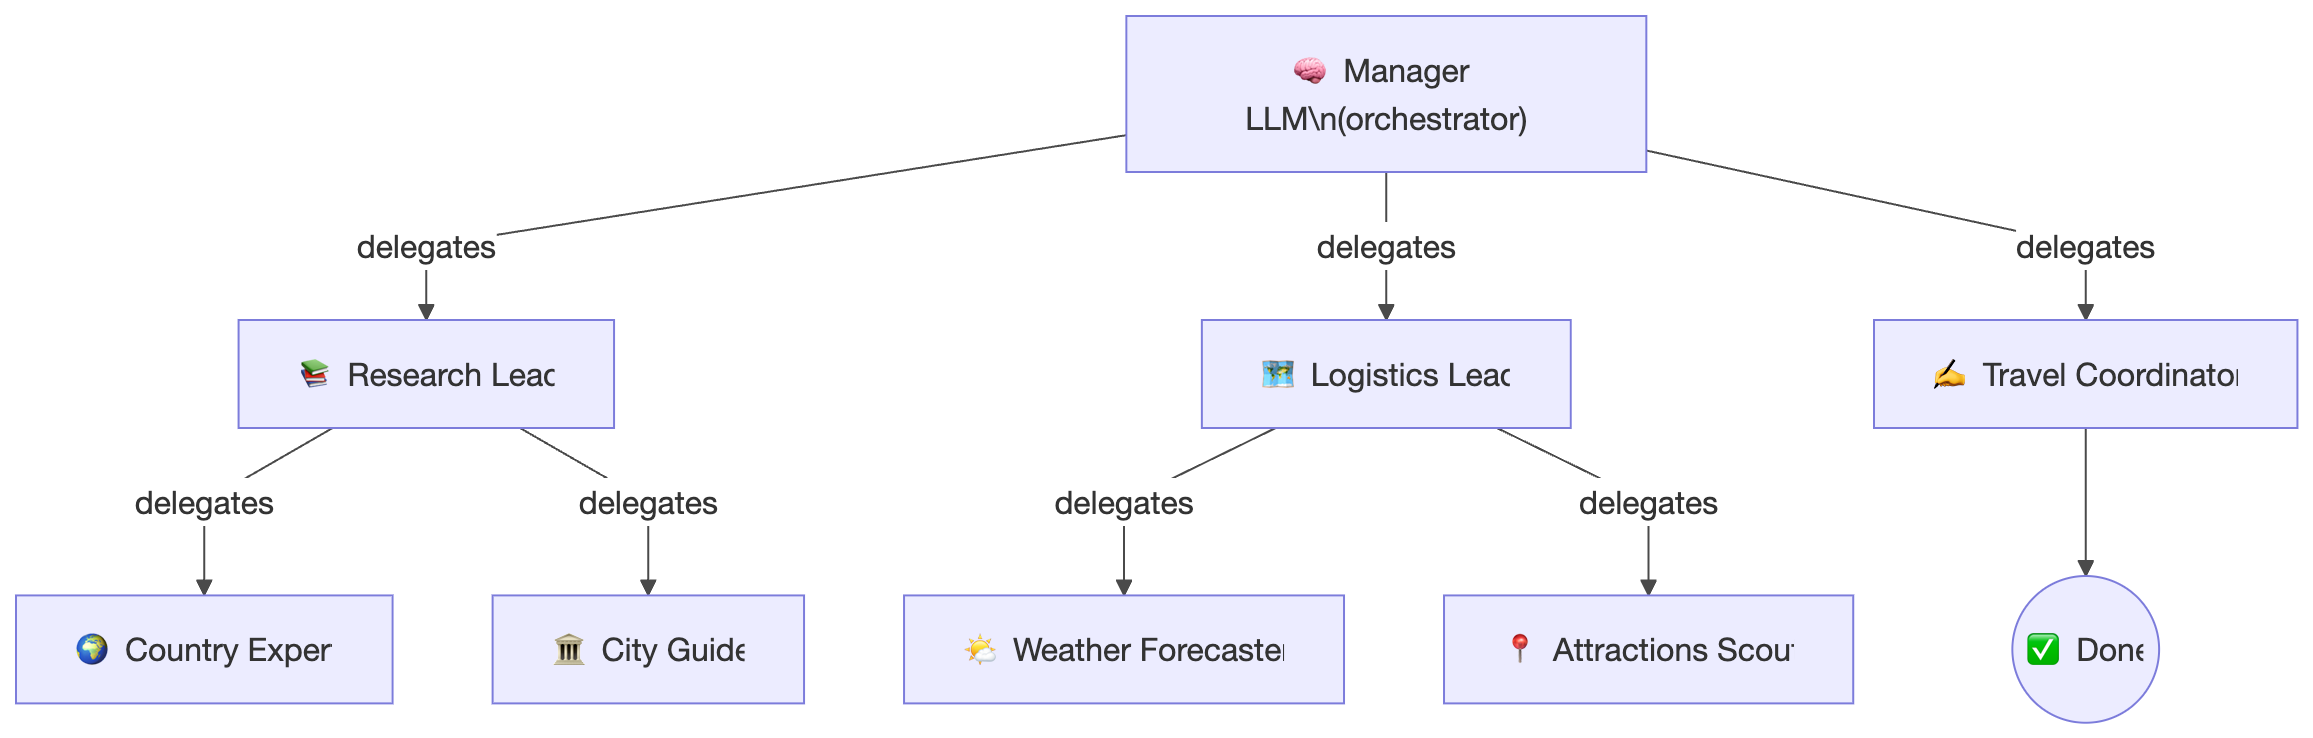

## Setup

### Dependencies

In [ ]:
%pip install -q crewai litellm requests

In [ ]:
import json
import requests
from crewai import Agent, Task, Crew, Process, LLM
from crewai.tools import tool

### Configuration

Set your API key, model name, and proxy URL here. No `.env` file needed.

In [ ]:
# Set values to connect to LiteLLM
LITELLM_API_KEY = "sk-ShWF2pBHZUsDR9Bs4RTVYg"
MODEL_NAME      = "openai/azure_ai/claude-sonnet-4-5-swc"
BASE_URL        = "https://litellm.artifact.swiss"

# Destination to research
DESTINATION = "Zürich"
COUNTRY = "Switzerland"

# Create LLM client
llm = LLM(
    model=MODEL_NAME,
    base_url=BASE_URL,
    api_key=LITELLM_API_KEY,
)

## Tools

Four tools that wrap **free, keyless APIs**. Each agent gets access to exactly one tool. CrewAI uses the `@tool` decorator to register them.

### Shared Helpers

A geocoding helper and constants shared across tools.

In [ ]:
WMO_CODES = {
    0: "Clear sky", 1: "Mainly clear", 2: "Partly cloudy",
    3: "Overcast", 45: "Foggy", 51: "Light drizzle",
    61: "Slight rain", 71: "Slight snow", 80: "Rain showers",
    95: "Thunderstorm",
}

WIKI_HEADERS = {"User-Agent": "TravelAgentWorkshop/1.0 (workshop demo)"}


def geocode(city_name: str) -> dict:
    """Resolve a city name to lat/lon using Open-Meteo's geocoding API."""
    resp = requests.get(
        "https://geocoding-api.open-meteo.com/v1/search",
        params={"name": city_name, "count": 1},
        timeout=10,
    ).json()
    if "results" not in resp or len(resp["results"]) == 0:
        return {"error": f"'{city_name}' not found"}
    return resp["results"][0]

### Country Info

Uses the [REST Countries API](https://restcountries.com/) to look up basic facts about a destination: official name, capital city, currency, spoken languages, population, and world region.

In [ ]:
@tool("Lookup Country Info")
def lookup_country(country_name: str) -> str:
    """Look up country facts like capital, currency, population, languages, and region."""
    try:
        resp = requests.get(
            f"https://restcountries.com/v3.1/name/{country_name}", timeout=10
        )
        resp.raise_for_status()
        data = resp.json()[0]
        return json.dumps({
            "name": data.get("name", {}).get("common"),
            "capital": data.get("capital"),
            "population": data.get("population"),
            "currencies": data.get("currencies"),
            "languages": data.get("languages"),
            "region": data.get("region"),
            "subregion": data.get("subregion"),
        }, default=str)
    except Exception as e:
        return json.dumps({"error": str(e)})

### Weather Forecast

Uses the [Open Meteo API](https://open-meteo.com/) to fetch current conditions and a 3 day forecast. Geocodes the city name first, then queries the forecast endpoint. A `WMO_CODES` lookup translates numeric weather codes to readable descriptions.

In [ ]:
@tool("Get Weather Forecast")
def get_weather(city_name: str) -> str:
    """Get current weather conditions and a 3-day forecast for a city."""
    try:
        loc = geocode(city_name)
        if "error" in loc:
            return json.dumps(loc)
        resp = requests.get(
            "https://api.open-meteo.com/v1/forecast",
            params={
                "latitude": loc["latitude"],
                "longitude": loc["longitude"],
                "current": "temperature_2m,weather_code,wind_speed_10m",
                "daily": "temperature_2m_max,temperature_2m_min",
                "forecast_days": 3,
                "timezone": "auto",
            },
            timeout=10,
        )
        resp.raise_for_status()
        data = resp.json()
        code = data.get("current", {}).get("weather_code")
        data["condition"] = WMO_CODES.get(code, f"Unknown (code {code})")
        return json.dumps(data, default=str)
    except Exception as e:
        return json.dumps({"error": str(e)})

### City Summary

Uses the [Wikipedia TextExtracts API](https://www.mediawiki.org/wiki/Extension:TextExtracts) to fetch a plain text extract of the city's article, covering history, geography, culture, and more in a single call.

In [ ]:
@tool("Get City Summary")
def get_city_summary(city_name: str) -> str:
    """Get a Wikipedia summary about a city covering history, culture, and geography."""
    try:
        resp = requests.get(
            "https://en.wikipedia.org/w/api.php",
            params={
                "action": "query",
                "titles": city_name,
                "prop": "extracts",
                "explaintext": True,
                "exchars": 4000,
                "format": "json",
            },
            headers=WIKI_HEADERS,
            timeout=10,
        ).json()
        pages = resp.get("query", {}).get("pages", {})
        page = next(iter(pages.values()), {})
        return page.get("extract", "") or "No Wikipedia article found."
    except Exception as e:
        return f"Error: {e}"

### Nearby Attractions

Uses Wikipedia's [geosearch API](https://www.mediawiki.org/wiki/Extension:GeoData) to find notable places near the destination. Reuses `geocode()` to resolve the city name to coordinates, then queries for Wikipedia articles within a 10 km radius.

In [ ]:
@tool("Find Nearby Attractions")
def find_attractions(city_name: str) -> str:
    """Find notable places and attractions near a city using Wikipedia GeoSearch."""
    try:
        loc = geocode(city_name)
        if "error" in loc:
            return json.dumps({"error": loc["error"]})
        resp = requests.get(
            "https://en.wikipedia.org/w/api.php",
            params={
                "action": "query",
                "list": "geosearch",
                "gscoord": f"{loc['latitude']}|{loc['longitude']}",
                "gsradius": 10000,
                "gslimit": 10,
                "format": "json",
            },
            headers=WIKI_HEADERS,
            timeout=10,
        ).json()
        places = resp.get("query", {}).get("geosearch", [])
        names = [p["title"] for p in places if p["title"].lower() != city_name.lower()]
        return json.dumps(names)
    except Exception as e:
        return json.dumps({"error": str(e)})

## Agents

Seven agents organised in three tiers. **Specialists** have `allow_delegation=False` (they do the actual work). **Team Leads** have `allow_delegation=True`, which gives them a built-in "Delegate work to coworker" tool so they can sub-delegate to the specialists in the crew. The **Travel Coordinator** synthesises everything at the end.

In [ ]:
# --- Tier 3: Specialists (do the actual work, no delegation) ---

country_expert = Agent(
    role="Country Expert",
    goal=(
        f"Provide key facts about {COUNTRY}: capital, population, currencies, "
        f"languages, and practical travel tips."
    ),
    backstory=(
        "You are a knowledgeable geopolitical analyst who specializes in "
        "providing concise, traveler-friendly country overviews."
    ),
    tools=[lookup_country],
    llm=llm,
    allow_delegation=False,
    verbose=True,
)

city_guide = Agent(
    role="City Guide",
    goal=(
        f"Provide a rich overview of {DESTINATION} covering history, culture, "
        f"notable neighborhoods, and what makes the city unique."
    ),
    backstory=(
        "You are a passionate local historian and cultural guide who brings "
        "cities to life through engaging storytelling."
    ),
    tools=[get_city_summary],
    llm=llm,
    allow_delegation=False,
    verbose=True,
)

weather_forecaster = Agent(
    role="Weather Forecaster",
    goal=(
        f"Provide current weather conditions and a 3-day forecast for {DESTINATION}, "
        f"with clothing and packing suggestions."
    ),
    backstory=(
        "You are a meteorologist who translates weather data into practical "
        "travel advice — what to wear, what to pack, what to expect."
    ),
    tools=[get_weather],
    llm=llm,
    allow_delegation=False,
    verbose=True,
)

attractions_scout = Agent(
    role="Attractions Scout",
    goal=(
        f"Find and describe the most interesting places, landmarks, and "
        f"hidden gems near {DESTINATION}."
    ),
    backstory=(
        "You are an adventurous travel scout who discovers both famous landmarks "
        "and off-the-beaten-path gems that make a trip memorable."
    ),
    tools=[find_attractions],
    llm=llm,
    allow_delegation=False,
    verbose=True,
)

# --- Tier 2: Team Leads (delegate to specialists) ---

research_lead = Agent(
    role="Research Lead",
    goal=(
        f"Coordinate comprehensive destination research for {DESTINATION} "
        f"by delegating to the Country Expert and City Guide."
    ),
    backstory=(
        "You are a senior researcher who manages a team of specialists. "
        "You never do research yourself — instead you delegate to the right "
        "expert and combine their findings into a coherent research brief."
    ),
    tools=[],
    llm=llm,
    allow_delegation=True,
    verbose=True,
)

logistics_lead = Agent(
    role="Logistics Lead",
    goal=(
        f"Coordinate practical travel logistics for {DESTINATION} "
        f"by delegating to the Weather Forecaster and Attractions Scout."
    ),
    backstory=(
        "You are a logistics coordinator who ensures travelers have all "
        "practical information they need. You delegate weather and attraction "
        "research to your team and compile the results."
    ),
    tools=[],
    llm=llm,
    allow_delegation=True,
    verbose=True,
)

# --- Tier 2: Synthesis ---

travel_coordinator = Agent(
    role="Travel Coordinator",
    goal=(
        f"Synthesize all research into a comprehensive, well-structured "
        f"travel guide for {DESTINATION}."
    ),
    backstory=(
        "You are a senior travel editor who combines diverse research into "
        "polished, actionable travel guides that travelers love."
    ),
    tools=[],
    llm=llm,
    allow_delegation=False,
    verbose=True,
)

all_agents = [
    research_lead, country_expert, city_guide,
    logistics_lead, weather_forecaster, attractions_scout,
    travel_coordinator,
]

print("🏢 Agent Hierarchy:")
print("   Manager LLM (orchestrator)")
print("   ├── 📚 Research Lead (delegates)")
print("   │     ├── 🌍 Country Expert")
print("   │     └── 🏛️ City Guide")
print("   ├── 🗺️ Logistics Lead (delegates)")
print("   │     ├── 🌤️ Weather Forecaster")
print("   │     └── 📍 Attractions Scout")
print("   └── ✍️ Travel Coordinator (synthesis)")

🏢 Agent Hierarchy:
   Manager LLM (orchestrator)
   ├── 📚 Research Lead (delegates)
   │     ├── 🌍 Country Expert
   │     └── 🏛️ City Guide
   ├── 🗺️ Logistics Lead (delegates)
   │     ├── 🌤️ Weather Forecaster
   │     └── 📍 Attractions Scout
   └── ✍️ Travel Coordinator (synthesis)


## Tasks

Only **three tasks** are defined at the top level. The leads' task descriptions instruct them to delegate sub-work to their specialists using the built-in "Delegate work to coworker" tool. The coordinator's **synthesis task** uses `context=[...]` to receive both leads' combined outputs.

In [ ]:
research_task = Task(
    description=(
        f"Coordinate destination research for {DESTINATION}, {COUNTRY}. "
        f"You must delegate the following sub-tasks to your coworkers:\n"
        f"1. Delegate to the **Country Expert** to look up country facts "
        f"(capital, population, currency, languages) using their tool.\n"
        f"2. Delegate to the **City Guide** to research the city's history, "
        f"culture, and character using their tool.\n"
        f"Combine both specialists' findings into a single research brief."
    ),
    expected_output=(
        "Combined research brief with country facts and city overview. "
        "Clearly label which information came from which specialist. Max 400 words."
    ),
    agent=research_lead,
)

logistics_task = Task(
    description=(
        f"Coordinate practical travel logistics for {DESTINATION}. "
        f"You must delegate the following sub-tasks to your coworkers:\n"
        f"1. Delegate to the **Weather Forecaster** to check current weather "
        f"and a 3-day forecast using their tool.\n"
        f"2. Delegate to the **Attractions Scout** to find nearby attractions "
        f"and landmarks using their tool.\n"
        f"Combine both specialists' findings into a single logistics brief."
    ),
    expected_output=(
        "Combined logistics brief with weather report and attractions list. "
        "Clearly label which information came from which specialist. Max 400 words."
    ),
    agent=logistics_lead,
)

synthesis_task = Task(
    description=(
        f"Combine all research into a travel guide for {DESTINATION} with sections:\n"
        f"- **Overview** — quick intro to the destination\n"
        f"- **Country Facts** — key info from the Research Lead\n"
        f"- **Weather & Packing** — from the Logistics Lead\n"
        f"- **City Highlights** — from the Research Lead\n"
        f"- **Must-See Attractions** — from the Logistics Lead\n"
        f"- **Pro Tips** — 3-5 practical travel tips"
    ),
    expected_output="Comprehensive travel guide in markdown format. Max 600 words.",
    agent=travel_coordinator,
    context=[research_task, logistics_task],
)

print(f"📋 {len([research_task, logistics_task, synthesis_task])} top-level tasks defined")
print(f"   Research Lead will sub-delegate to Country Expert + City Guide")
print(f"   Logistics Lead will sub-delegate to Weather Forecaster + Attractions Scout")
print(f"   Travel Coordinator synthesises all outputs")

📋 3 top-level tasks defined
   Research Lead will sub-delegate to Country Expert + City Guide
   Logistics Lead will sub-delegate to Weather Forecaster + Attractions Scout
   Travel Coordinator synthesises all outputs


## Build & Run

We use `Process.hierarchical` where a **Manager LLM** sits at the top and delegates tasks to the leads. The leads then use their `allow_delegation=True` capability to sub-delegate to specialists. This creates a visible 3-tier delegation chain: Manager → Leads → Specialists → Coordinator.

In [ ]:
crew = Crew(
    agents=all_agents,
    tasks=[research_task, logistics_task, synthesis_task],
    process=Process.hierarchical,
    manager_llm=llm,
    verbose=True,
    memory=False,
)

print(f"🚀 Crew assembled — {len(crew.agents)} agents, {len(crew.tasks)} tasks")
print(f"   Process: Hierarchical (3-tier delegation)")
print(f"   Tier 1: Manager LLM (orchestrator)")
print(f"   Tier 2: Research Lead, Logistics Lead (delegate)")
print(f"   Tier 3: 4 specialists + Travel Coordinator")
print(f"   LLM: {llm.model}")

🚀 Crew assembled — 7 agents, 3 tasks
   Process: Hierarchical (3-tier delegation)
   Tier 1: Manager LLM (orchestrator)
   Tier 2: Research Lead, Logistics Lead (delegate)
   Tier 3: 4 specialists + Travel Coordinator
   LLM: openai/azure_ai/claude-sonnet-4-5-swc


In [ ]:
result = crew.kickoff()

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 7bf8598a-102a-4c66-9d1e-f6f0def56e1e                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Coordinate destination research for Zürich, Switzerland. You must delegate the following sub-tasks to    │
│  your coworkers:                                                                                                │
│  1. Delegate to the **Country Expert** to look up country facts (capital, population, currency, languages)      │
│  using their tool.                                                                                              │
│  2. Delegate to the **City Guide** to research the city's history, culture, and character using their tool.     │
│  Combine both specialists' findings into a single research brief.                                               │
│  ID: 1c98986c-f827-4e84-a052-76a488a72ea6                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Crew Manager                                                                                            │
│                                                                                                                 │
│  Task: Coordinate destination research for Zürich, Switzerland. You must delegate the following sub-tasks to    │
│  your coworkers:                                                                                                │
│  1. Delegate to the **Country Expert** to look up country facts (capital, population, currency, languages)      │
│  using their tool.                                                                                              │
│  2. Delegate to the **City Guide** to research the city's history, culture, and character using their tool.     │
│  Combine both specialists' findings into a single research brief.                                               │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────── 🔧 Tool Execution Started (#5) ─────────────────────────────────────────╮
│                                                                                                                 │
│  Tool: delegate_work_to_coworker                                                                                │
│  Args: {"task": "Research country facts for Switzerland", "context": "I need you to look up comprehensive       │
│  country facts for Switzerland using your tool. Please provide the following information: capital city...       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Research Lead                                                                                           │
│                                                                                                                 │
│  Task: Research country facts for Switzerland                                                                   │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Coordinate practical travel logistics for Zürich. You must delegate the following sub-tasks to your      │
│  coworkers:                                                                                                     │
│  1. Delegate to the **Weather Forecaster** to check current weather and a 3-day forecast using their tool.      │
│  2. Delegate to the **Attractions Scout** to find nearby attractions and landmarks using their tool.            │
│  Combine both specialists' findings into a single logistics brief.                                              │
│  Agent: Crew Manager                                                                                            │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Combine all research into a travel guide for Zürich with sections:                                       │
│  - **Overview** — quick intro to the destination                                                                │
│  - **Country Facts** — key info from the Research Lead                                                          │
│  - **Weather & Packing** — from the Logistics Lead                                                              │
│  - **City Highlights** — from the Research Lead                                                                 │
│  - **Must-See Attractions** — from the Logistics Lead                                                           │
│  - **Pro Tips** — 3-5 practical travel tips                                                                     │
│  ID: 0ffbc6ca-6c08-4cb2-b402-81967884d803                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Crew Manager                                                                                            │
│                                                                                                                 │
│  Task: Combine all research into a travel guide for Zürich with sections:                                       │
│  - **Overview** — quick intro to the destination                                                                │
│  - **Country Facts** — key info from the Research Lead                                                          │
│  - **Weather & Packing** — from the Logistics Lead                                                              │
│  - **City Highlights** — from the Research Lead                                                                 │
│  - **Must-See Attractions** — from the Logistics Lead                                                           │
│  - **Pro Tips** — 3-5 practical travel tips                                                                     │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Crew Manager                                                                                            │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  # ZÜRICH, SWITZERLAND: COMPLETE TRAVEL GUIDE                                                                   │
│                                                                                                                 │
│  ## Overview                                                                                                    │
│                                                                                                                 │
│  Zürich, Switzerland's largest city, masterfully blends its 2,000-year history with modern sophistication.      │
│  From its Roman origins as "Turicum" to today's global financial powerhouse, Zürich offers visitors a unique    │
│  experience where medieval Old Town charm meets cosmopolitan culture. Nestled at the northwestern tip of Lake   │
│  Zürich with the Alps as backdrop, this consistently top-ranked livable city delivers world-class museums,      │
│  Michelin-starred dining, luxury shopping, and stunning natural beauty—all within a compact, walkable center.   │
│                                                                                                                 │
│  ## Country Facts                                                                                               │
│                                                                                                                 │
│  **Capital:** Bern (de facto federal city)                                                                      │
│  **Population:** Approximately 8.7-8.8 million                                                                  │
│  **Currency:** Swiss Franc (CHF)                                                                                │
│  **Languages:** Four official languages—German (63%), French (23%), Italian (8%), and Romansh (<1%). Zürich is  │
│  in the German-speaking region, where locals speak Swiss German dialect daily, though most residents are        │
│  multilingual and English is widely understood.                                                                 │
│                                                                                                                 │
│  ## Weather & Packing                                                                                           │
│                                                                                                                 │
│  Zürich's location near Lake Zürich and the Alps creates variable weather conditions. Mountain weather systems  │
│  can move quickly, so check forecasts regularly before your trip.                                               │
│                                                                                                                 │
│  **Weather Resources:** Consult MeteoSwiss (www.meteoswiss.admin.ch), Weather.com, or Yr.no for current         │
│  conditions and 3-day forecasts including temperature, precipitation probability, and weather alerts.           │
│                                                                                                                 │
│  **Packing Essentials:** Layers are key due to variable conditions. Bring comfortable walking shoes for         │
│  cobblestone streets, weather-appropriate outerwear, and smart-casual attire for upscale dining. Don't forget   │
│  sunglasses and sunscreen for lakeside activities.     

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Combine all research into a travel guide for Zürich with sections:                                       │
│  - **Overview** — quick intro to the destination                                                                │
│  - **Country Facts** — key info from the Research Lead                                                          │
│  - **Weather & Packing** — from the Logistics Lead                                                              │
│  - **City Highlights** — from the Research Lead                                                                 │
│  - **Must-See Attractions** — from the Logistics Lead                                                           │
│  - **Pro Tips** — 3-5 practical travel tips                                                                     │
│  Agent: Crew Manager                                                                                            │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Results

After the crew finishes, we inspect the **delegation chain**: which lead handled which task, and which specialists they sub-delegated to. Then we read the leads' combined briefs and the final travel guide.

In [ ]:
print("🏢 DELEGATION CHAIN")
print("=" * 60)
print()
print("  🧠 Manager LLM (orchestrator)")
print("  │")

task_labels = {
    id(research_task): ("📚 Research Lead", [
        ("🌍 Country Expert", "country facts"),
        ("🏛️ City Guide", "city overview"),
    ]),
    id(logistics_task): ("🗺️ Logistics Lead", [
        ("🌤️ Weather Forecaster", "weather forecast"),
        ("📍 Attractions Scout", "nearby attractions"),
    ]),
    id(synthesis_task): ("✍️ Travel Coordinator", []),
}

all_tasks = [research_task, logistics_task, synthesis_task]

for i, task_out in enumerate(result.tasks_output):
    # Match output to our task
    matched_task_id = None
    for t in all_tasks:
        if t.description and task_out.description and t.description[:50] == task_out.description[:50]:
            matched_task_id = id(t)
            break

    if matched_task_id and matched_task_id in task_labels:
        label, specialists = task_labels[matched_task_id]
        is_last_task = (i == len(result.tasks_output) - 1)
        branch = "└" if is_last_task else "├"
        cont = " " if is_last_task else "│"

        print(f"  {branch}── delegated to: {label}")
        print(f"  {cont}   │  📝 {len(task_out.raw)} chars output")

        for j, (spec_label, spec_job) in enumerate(specialists):
            is_last_spec = (j == len(specialists) - 1)
            spec_branch = "└" if is_last_spec else "├"
            print(f"  {cont}   {spec_branch}── sub-delegated to: {spec_label} ({spec_job})")

        if specialists:
            print(f"  {cont}")
    else:
        is_last_task = (i == len(result.tasks_output) - 1)
        branch = "└" if is_last_task else "├"
        print(f"  {branch}── Step {i+1}: {len(task_out.raw)} chars output")

🏢 DELEGATION CHAIN

  🧠 Manager LLM (orchestrator)
  │
  ├── delegated to: 📚 Research Lead
  │   │  📝 2340 chars output
  │   ├── sub-delegated to: 🌍 Country Expert (country facts)
  │   └── sub-delegated to: 🏛️ City Guide (city overview)
  │
  ├── delegated to: 🗺️ Logistics Lead
  │   │  📝 2178 chars output
  │   ├── sub-delegated to: 🌤️ Weather Forecaster (weather forecast)
  │   └── sub-delegated to: 📍 Attractions Scout (nearby attractions)
  │
  └── delegated to: ✍️ Travel Coordinator
      │  📝 4094 chars output


╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 7bf8598a-102a-4c66-9d1e-f6f0def56e1e                                                                       │
│  Final Output: # ZÜRICH, SWITZERLAND: COMPLETE TRAVEL GUIDE                                                     │
│                                                                                                                 │
│  ## Overview                                                                                                    │
│                                                                                                                 │
│  Zürich, Switzerland's largest city, masterfully blends its 2,000-year history with modern sophistication.      │
│  From its Roman origins as "Turicum" to today's global financial powerhouse, Zürich offers visitors a unique    │
│  experience where medieval Old Town charm meets cosmopolitan culture. Nestled at the northwestern tip of Lake   │
│  Zürich with the Alps as backdrop, this consistently top-ranked livable city delivers world-class museums,      │
│  Michelin-starred dining, luxury shopping, and stunning natural beauty—all within a compact, walkable center.   │
│                                                                                                                 │
│  ## Country Facts                                                                                               │
│                                                                                                                 │
│  **Capital:** Bern (de facto federal city)                                                                      │
│  **Population:** Approximately 8.7-8.8 million                                                                  │
│  **Currency:** Swiss Franc (CHF)                                                                                │
│  **Languages:** Four official languages—German (63%), French (23%), Italian (8%), and Romansh (<1%). Zürich is  │
│  in the German-speaking region, where locals speak Swiss German dialect daily, though most residents are        │
│  multilingual and English is widely understood.                                                                 │
│                                                                                                                 │
│  ## Weather & Packing                                                                                           │
│                                                                                                                 │
│  Zürich's location near Lake Zürich and the Alps creates variable weather conditions. Mountain weather systems  │
│  can move quickly, so check forecasts regularly before your trip.                                               │
│                                                                                                                 │
│  **Weather Resources:** Consult MeteoSwiss (www.meteoswiss.admin.ch), Weather.com, or Yr.no for current         │
│  conditions and 3-day forecasts including temperature, precipitation probability, and weather alerts.           │
│                                                                                                                 │
│  **Packing Essentials:** Layers are key due to variable conditions. Bring comfortable walking shoes for         │
│  cobblestone streets, weather-appropriate outerwear, and smart-casual attire for upscale dining. Don't forget   │
│  sunglasses and sunscreen for lakeside activities.    

### Team Lead Briefs

Each team lead collected their specialists' outputs and compiled a combined brief. These are the intermediate results before the Travel Coordinator synthesised them.

In [ ]:
briefs = [
    ("📚 Research Lead (Country Expert + City Guide)", research_task),
    ("🗺️ Logistics Lead (Weather Forecaster + Attractions Scout)", logistics_task),
]

for label, task in briefs:
    print(f"\n{'=' * 60}")
    print(f"  {label}")
    print(f"{'=' * 60}")
    if task.output:
        print(task.output.raw)
    else:
        print("   (no output)")




  📚 Research Lead (Country Expert + City Guide)
**DESTINATION RESEARCH BRIEF: ZÜRICH, SWITZERLAND**

---

**COUNTRY FACTS (provided by Country Expert):**

**Capital City:** Bern (de facto capital; Switzerland technically has no official capital, but Bern serves as the federal city where the government is seated)

**Population:** Approximately 8.7-8.8 million people (as of 2023-2024)

**Currency:** Swiss Franc (CHF)

**Official Languages:** Switzerland has four official languages:
- German (spoken by about 63% of the population)
- French (spoken by about 23% of the population)
- Italian (spoken by about 8% of the population)
- Romansh (spoken by less than 1% of the population)

*Note: Zürich is located in the German-speaking region.*

---

**CITY OVERVIEW (provided by City Guide):**

**History:** Zürich's 2,000-year history began as Roman customs post "Turicum" (15 BC). It became a free imperial city in 1218, joined the Swiss Confederation in 1351, and emerged as a Protestant Reforma

### Final Travel Guide

The Travel Coordinator's synthesised output, combining all specialist research into a single comprehensive guide.

In [ ]:
print(f"📝 TRAVEL GUIDE: {DESTINATION.upper()}")
print("=" * 60)
print(result.raw)



📝 TRAVEL GUIDE: ZÜRICH
╭────────────────────────── Tracing Preference Saved ──────────────────────────╮
│                                                                              │
│  Info: Tracing has been disabled.                                            │
│                                                                              │
│  Your preference has been saved. Future Crew/Flow executions will not        │
│  collect traces.                                                             │
│                                                                              │
│  To enable tracing later, do any one of these:                               │
│  • Set tracing=True in your Crew/Flow code                                   │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file               │
│  • Run: crewai traces enable                                                 │
│                                                                              │
╰──